In [ ]:
import sys
sys.path.append("..")
from src.utils import set_seed, get_device
from src.data import build_dataloaders
from src.models import build_model
from src.train import fit_model, plot_results
import torch
import gdown
import zipfile
from pathlib import Path

In [ ]:
PROJECT_DIR = Path.cwd()
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

DATASET_DIR = PROJECT_DIR / "data" / "avito_dataset"
TRAIN_DIR = DATASET_DIR / "train"
VAL_DIR = DATASET_DIR / "val"

In [ ]:
FILE_ID = "1QeKnNsCiVUbwVMz_nHqHwlwnIH2PGQDM"

ARCHIVE_PATH = PROJECT_DIR / "data" / "avito_dataset.zip"

gdown.download(
    id=FILE_ID,
    output=str(ARCHIVE_PATH),
    quiet=False
)

In [ ]:
with zipfile.ZipFile(ARCHIVE_PATH, "r") as z:
    z.extractall(DATASET_DIR)

print("Архив успешно распакован")

In [ ]:
set_seed(42)
device = get_device()

In [ ]:
train_loader, val_loader = build_dataloaders(TRAIN_DIR, VAL_DIR, batch_size=128)

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

**ResNet18**

In [ ]:
model_resnet = build_model("resnet18").to(device)
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)
model_resnet, history_df_resnet18 = fit_model(model_resnet, train_loader, val_loader, optimizer, device, epochs=10)

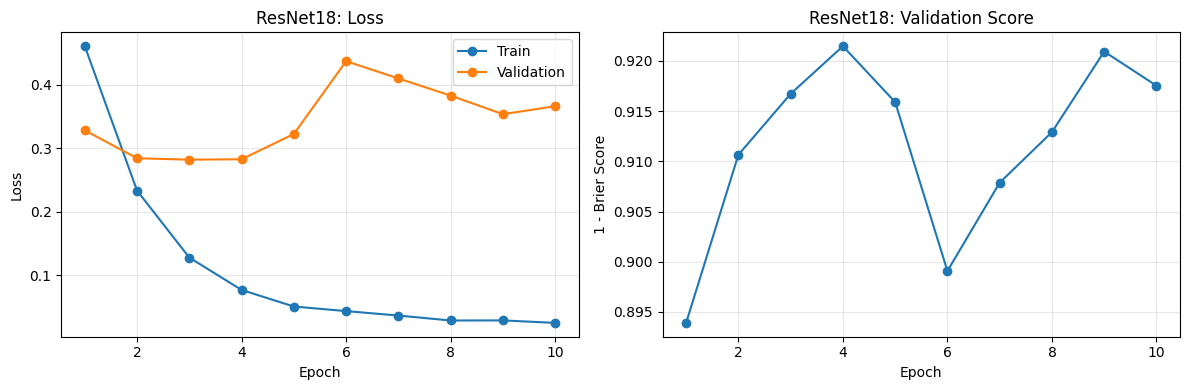

In [ ]:
plot_results(history_df_resnet18)

**EfficientNet-B0**

In [ ]:
train_loader, val_loader = build_dataloaders(TRAIN_DIR, VAL_DIR, batch_size=128)

In [ ]:
model_efficientnet = build_model("efficientnet_b0").to(device)
optimizer = torch.optim.Adam(model_efficientnet.parameters(), lr=1e-4)
model_efficientnet, history_df_efficientnet = fit_model(model_efficientnet, train_loader, val_loader, optimizer, device, epochs=10)

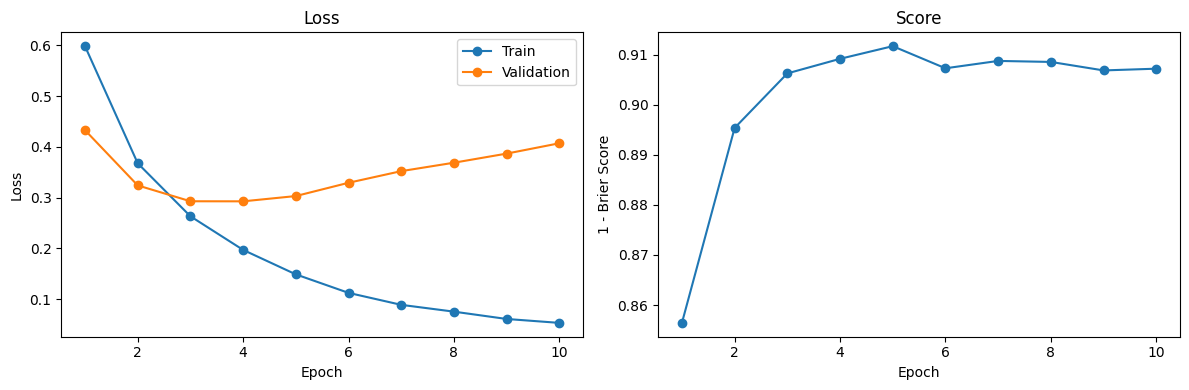

In [ ]:
plot_results(history_df_efficientnet)

**MobileNetV3 Small**

In [ ]:
train_loader, val_loader = build_dataloaders(TRAIN_DIR, VAL_DIR, batch_size=128)

In [ ]:
model_mobilenet = build_model("mobilenet_v3_small").to(device)
optimizer = torch.optim.Adam(model_mobilenet.parameters(), lr=1e-4)
model_mobilenet, history_df_mobilenet = fit_model(model_mobilenet, train_loader, val_loader, optimizer, device, epochs=10)

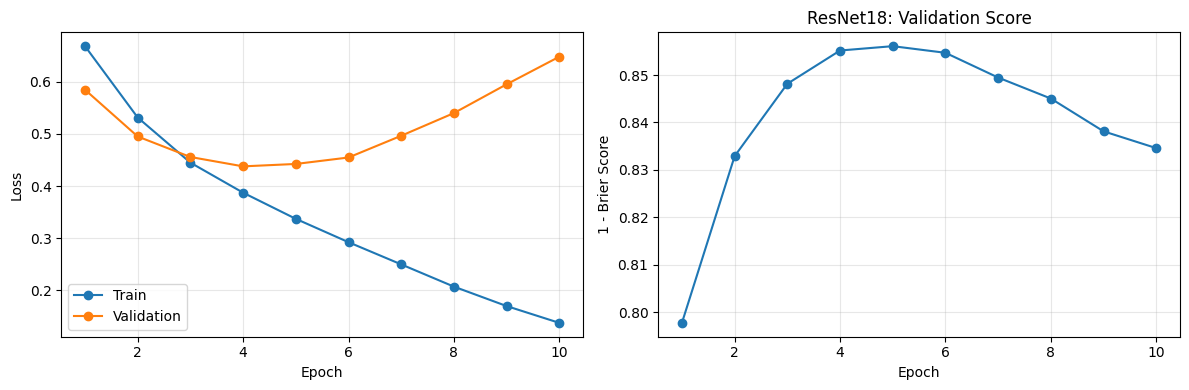

In [ ]:
plot_results(history_df_mobilenet)

**ShuffleNetV2 (x1.0)**

In [ ]:
train_loader, val_loader = build_dataloaders(TRAIN_DIR, VAL_DIR, batch_size=128)

In [ ]:
model_shufflenet = build_model("shufflenet_v2").to(device)
optimizer = torch.optim.Adam(model_shufflenet.parameters(), lr=1e-4)
model_shufflenet, history_df_shufflenet = fit_model(model_shufflenet, train_loader, val_loader, optimizer, device, epochs=10)

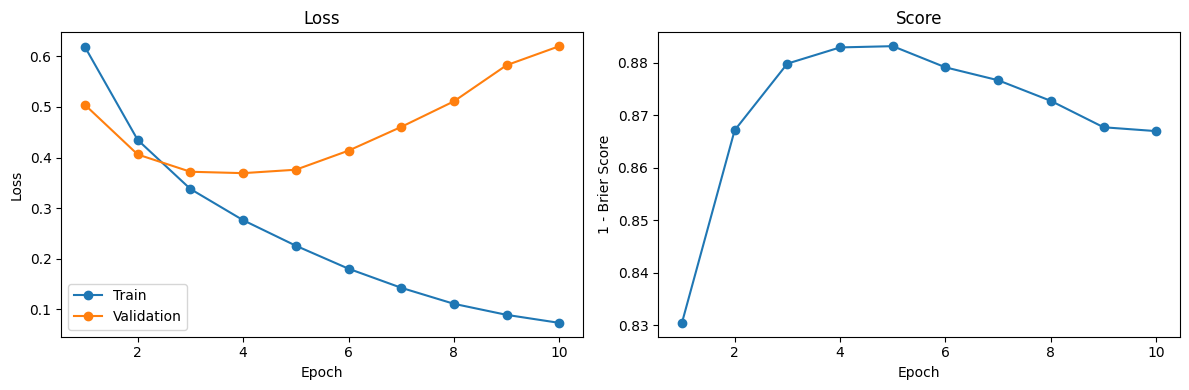

In [ ]:
plot_results(history_df_shufflenet)

**Выбор лучшей модели**

После 4-5 эпохи все модели переобучаются

Лучшие промежуточные результаты показала модель ResNet18 (около 92.2% максимум по  метрике на валидационной выборке)

Поработаем с входными данными, попробуем сделать аугментацию данных (главное, без поворотов и флипов)

In [ ]:
train_loader, val_loader = build_dataloaders(TRAIN_DIR, VAL_DIR, batch_size=128, is_aug = True)

In [ ]:
model_resnet = build_model("resnet18").to(device)
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=1e-4)
model_resnet, history_df_resnet18 = fit_model(model_resnet, train_loader, val_loader, optimizer, device, epochs=10)

In [ ]:
plot_results(history_df_resnet18)

*некоторые эксперименты проводились с помощью gpu в kaggle*

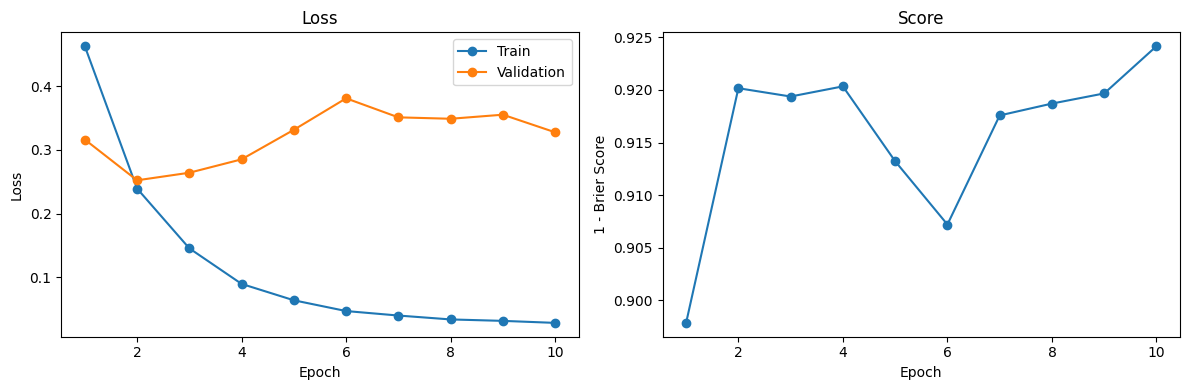

Получилось чуть лучше по результатам и чуть более стабильно

Если уменьшить batch_size до 32 (получается стабильнее):

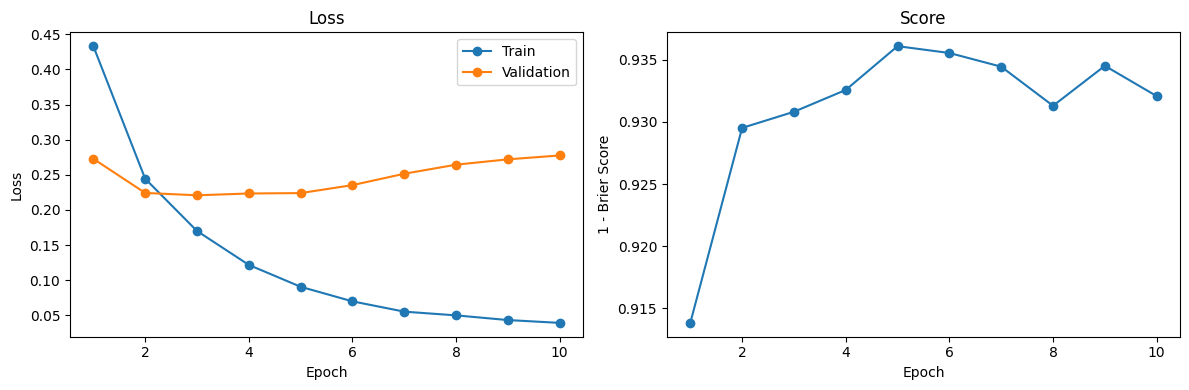

In [ ]:
best_model_name = "resnet18"

Обучим модель для инференса

In [ ]:
CHECKPOINTS_DIR = Path("../checkpoints")

In [ ]:
train_loader, val_loader = build_dataloaders(TRAIN_DIR, VAL_DIR, batch_size=32, is_aug = True)

In [ ]:
best_model = build_model(best_model_name).to(device)
optimizer = torch.optim.Adam(best_model.parameters(), lr=1e-4)
best_model, history_best = fit_model(best_model, train_loader, val_loader, optimizer, device, epochs=10, checkpoint_path=CHECKPOINTS_DIR / f"{best_model_name}_best.pth")

plot_results(history_best)